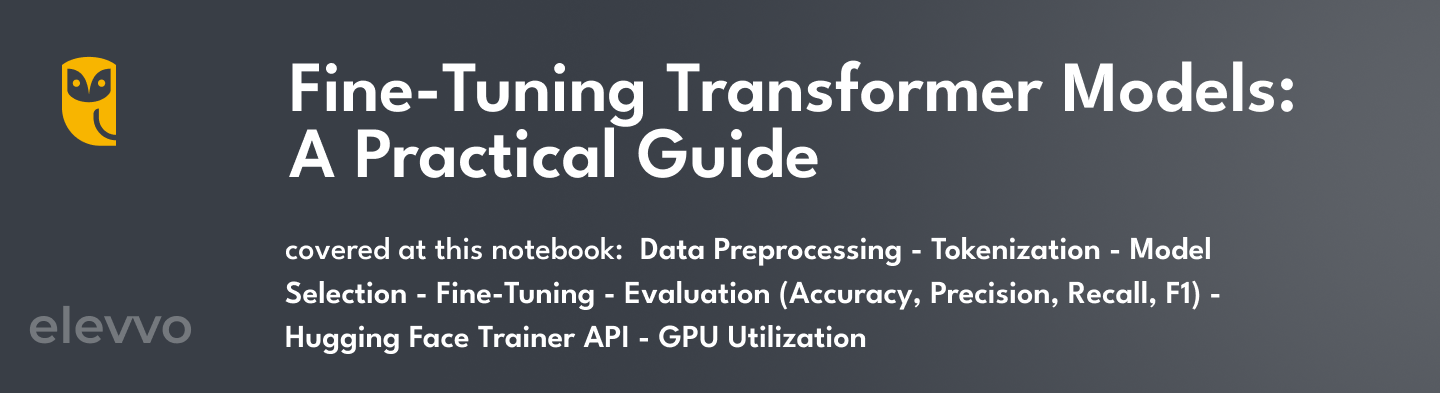

📌 First Step: `Make sure to change the runtime type to 'T4 GPU' (or any available GPU)` as declared in the next screenshots, to enable faster training.

*CPU can be used but will be much slower*

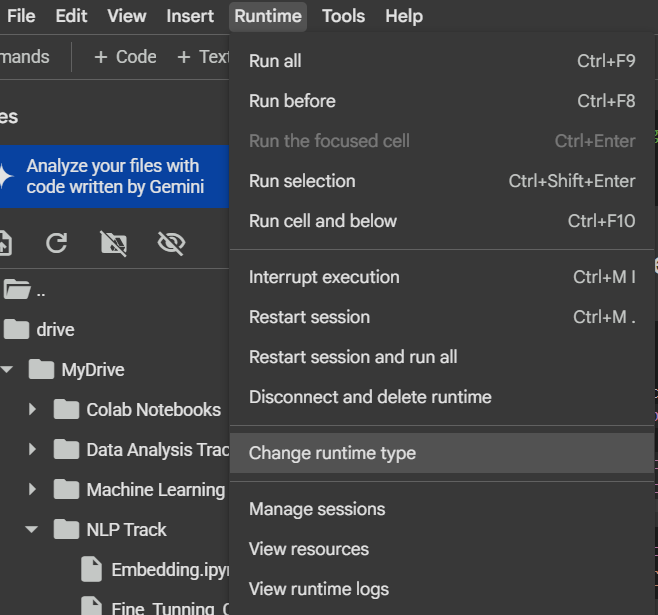

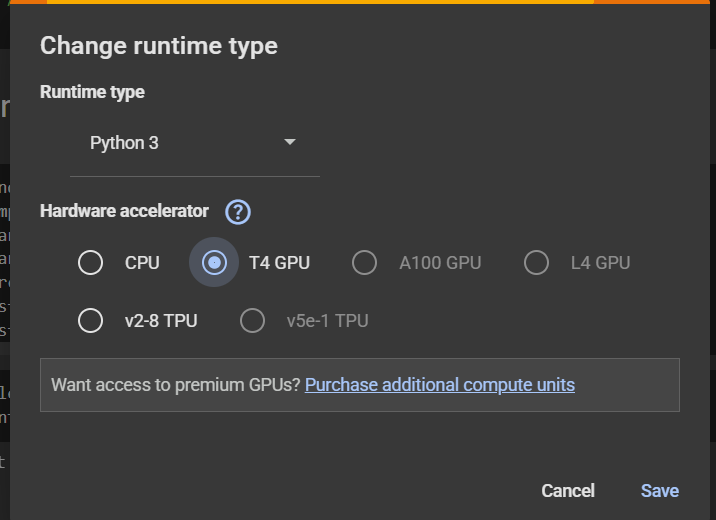

#Introduction

📌 in this notebook, we will do fine-tuning a pretrained Hugging Face transformer models for text classification (spam or not spam)

📌 Transformer is a neural network architecture used for performing machine learning tasks particularly in natural language processing (NLP) and computer vision. In 2017 Vaswani et al. published a paper ” Attention is All You Need” in which the transformers architecture was introduced. The article explores the architecture, workings and applications of transformers.

📌 Transformer Architecture is a model that uses self-attention to transform one whole sentence into a single sentence. This is useful where older models work step by step and it helps overcome the challenges seen in models like RNNs and LSTMs.

📌 If you're looking for the theoretical foundation of Transformers, the original paper is:

📄 "[Attention is All You Need](https://arxiv.org/abs/1706.03762)"

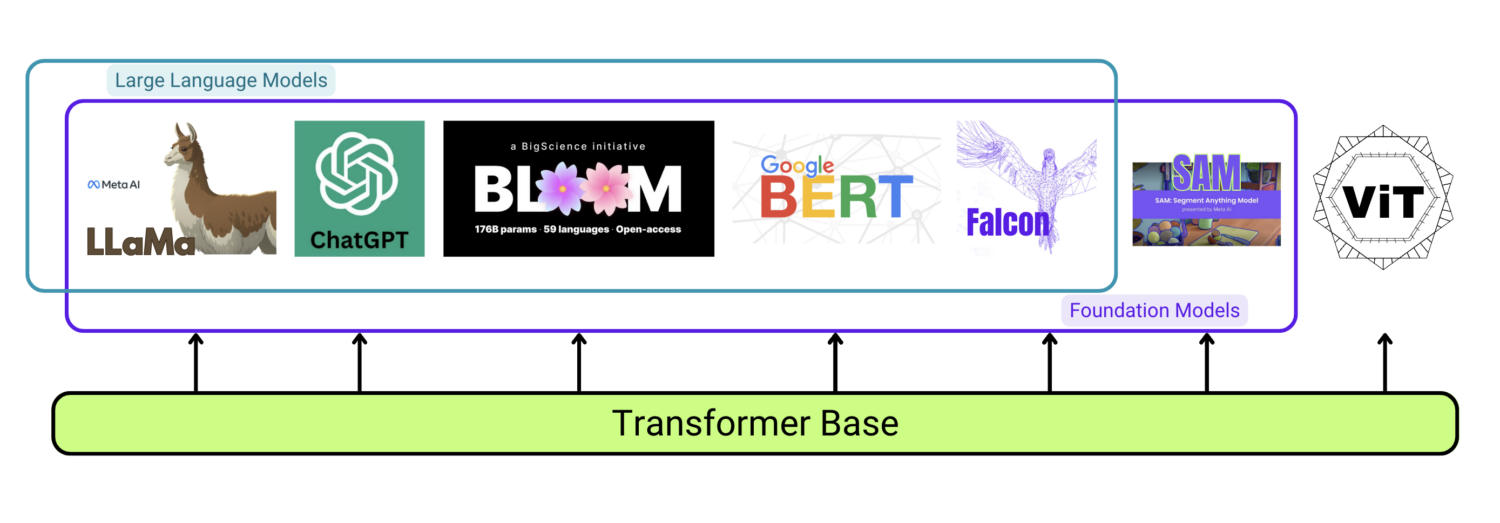

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import torch
from transformers import TrainingArguments, Trainer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Reading Data

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/NLP Track/3- Transformers/spam.csv', encoding='latin-1')
data = data.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis = 1)
data.rename(columns = {'v1' : 'Spam', 'v2' : 'Text'}, inplace=True)
data['Spam'] = data['Spam'].map({'spam' : 1, 'ham' : 0})
data.head()

,Spam,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


📌 examples of the text from the dataset

In [ ]:
data['Text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [ ]:
data['Text'][8]

'WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.'

# Downloading and Loading our model

📌 `"bert-base-uncased"` is a transformer-based language model. It processes text without case sensitivity, understanding word relationships for various NLP tasks. Pre-trained on a massive dataset, it's fine-tuned for specific applications like spam detection.

In [ ]:
#handling tokenization to prepare the text for BERT.
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

#load a pre-trained BERT model for sequence classification.
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased',num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Preparing Data

`Parameters in the next cell` -	Explanation

`X`	Input texts

`y`	Target labels

`X_train`	Training texts

`X_val`	Validation texts

`y_train`	Training labels

`y_val`	Validation labels

`test_size`	Validation split

`stratify`	Balanced splits (ensures balanced class distribution in splits.)

`padding`	Equal length (Adds tokens to short sequences for uniformity)

`truncation`	Limit length (Cuts long sequences to fit model input)

`max_length`	Input size

`📌 Validation` here means: Model tuning, hyperparameter adjustment. Testing: Final evaluation, unseen data performance.

In [ ]:
X = list(data["Text"])
y = list(data["Spam"])
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2,stratify=y)
X_train_tokenized = tokenizer(X_train, padding=True, truncation=True, max_length=512)
X_val_tokenized = tokenizer(X_val, padding=True, truncation=True, max_length=512)

📌 The tokenizer function produces a dictionary containing essential information for the machine learning model. X_train_tokenized.keys() allows you to access the names of these data components (keys) for further processing or inspection.

In [ ]:
X_train_tokenized.keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])



```



```



📌 1. input_ids:

`What it is:` A sequence of numerical IDs representing the tokens in your text. Each unique token in the tokenizer's vocabulary has a corresponding numerical ID.

`Purpose:` This is the primary input to the model. The model uses these IDs to look up the embeddings (vector representations) for each token.

`Example:` If the sentence "Hello, world!" is tokenized into ["Hello", ",", "world", "!"], the input_ids might be something like [123, 456, 789, 1011].

📌 2. token_type_ids:

`What it is:` A sequence of IDs indicating which segment a token belongs to. This is primarily used for tasks involving multiple text segments, like question answering or sentence pair classification.

`Purpose:` Helps the model differentiate between segments in the input. For example, in a question-answering task, it can distinguish between the question and the context passage.

`Example:` If you have two sentences, "This is the first sentence." and "This is the second sentence.", the token_type_ids might be [0, 0, 0, 0, 0, 0] for the first sentence and [1, 1, 1, 1, 1, 1] for the second sentence.

📌 3. attention_mask:

`What it is:` A sequence of 0s and 1s indicating which tokens should be attended to by the model.

`Purpose:` Used to handle padding. When sequences are padded to a fixed length, the attention_mask tells the model to ignore the padding tokens (represented by 0s) and focus on the real tokens (represented by 1s).

`Example:` If a sequence is padded with two [PAD] tokens at the end, the attention_mask might be [1, 1, 1, 1, 0, 0].



```



```



In [ ]:
len(X_train),len(X_val)

(4457, 1115)

📌 Then we will define custom dataset class called Dataset which inherits from PyTorch's torch.utils.data.Dataset. This is a standard way to create datasets in PyTorch for training and evaluation.

Here's a brief explanation of what each part does:

📌 `__init__(self, encodings, labels=None):` This is the constructor of the class. It initializes the dataset with encodings (the output of a tokenizer we used earlier) and optionally labels.

📌 `__getitem__(self, idx):` This method is called when you try to access an item from the dataset using an index (idx).

It retrieves the data for the given index from the encodings dictionary and converts it to a PyTorch tensor. If labels are provided, it also retrieves the label for the index and converts it to a tensor, ensuring it's a numerical type. It returns a dictionary containing the data and label (if available).

`📌 Note: Tensors are multi-dimensional arrays that can hold numerical data and are used in deep learning frameworks like PyTorch`

📌 `__len__(self):` This method returns the total number of samples in the dataset, determined by the length of the input_ids in the encodings.

In [ ]:
# Create torch dataset
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels:
            # Convert labels to numerical type if they are strings
            item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [ ]:
train_dataset = Dataset(X_train_tokenized, y_train)
val_dataset = Dataset(X_val_tokenized, y_val)

In [ ]:
train_dataset[5]

{'input_ids': tensor([  101,  2489,  4443,  2000,  1996, 24665,  2620, 18098, 10057,  1059,
          2243,  2135,  4012,  2361,  1018,  1037,  3382,  2000,  2663,  1996,
          6745, 22098, 26839,  2692,  1010,  8827,  2361,  2030,  1037, 29646,
         17788,  2692,  5356,  2296,  1059,  2243,  1012, 19067,  2102,  2307,
          2000,  3770,  2620,  2581,  2620,  8299,  1013,  1013,  7479,  1012,
         24665,  2620, 18098, 10057,  1012,  4012,  5511,  2581, 16068, 19841,
         12376, 19317,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [ ]:
def compute_metrics(p):
    print(type(p))
    pred, labels = p
    pred = np.argmax(pred, axis=1)

    accuracy = accuracy_score(y_true=labels, y_pred=pred)
    recall = recall_score(y_true=labels, y_pred=pred)
    precision = precision_score(y_true=labels, y_pred=pred)
    f1 = f1_score(y_true=labels, y_pred=pred)

    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

# Fine-Tunning the Model

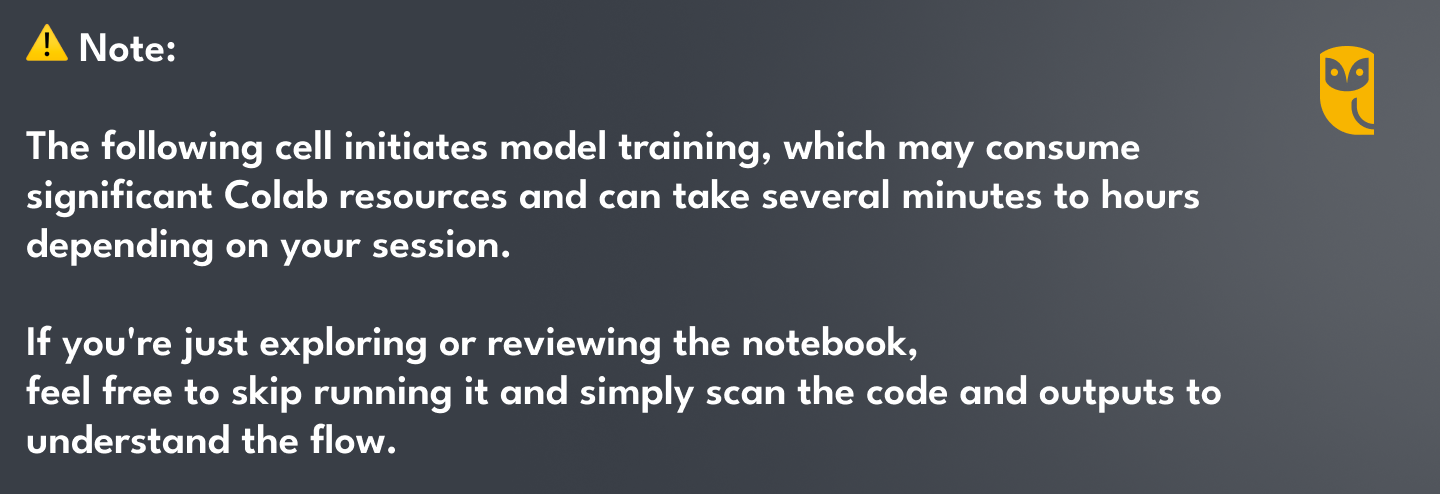

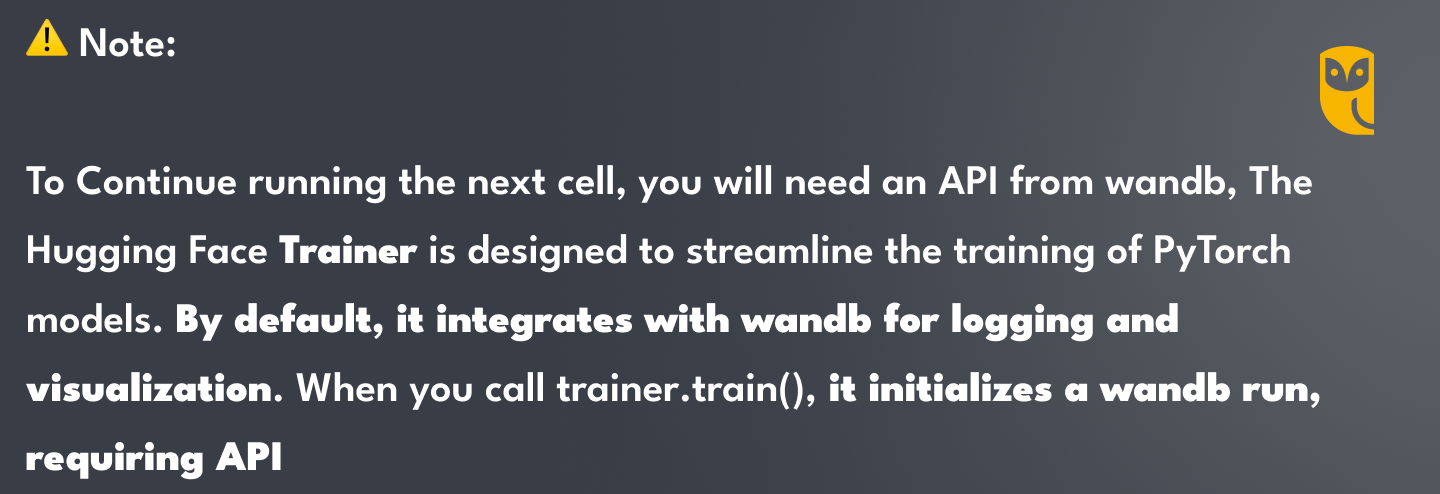

📌 `wandb (Weights & Biases)` is a platform and a Python library designed to help track and manage machine learning experiments. It offers variety of tools

📌To get the API, visit `https://wandb.ai/home` and `sign up`

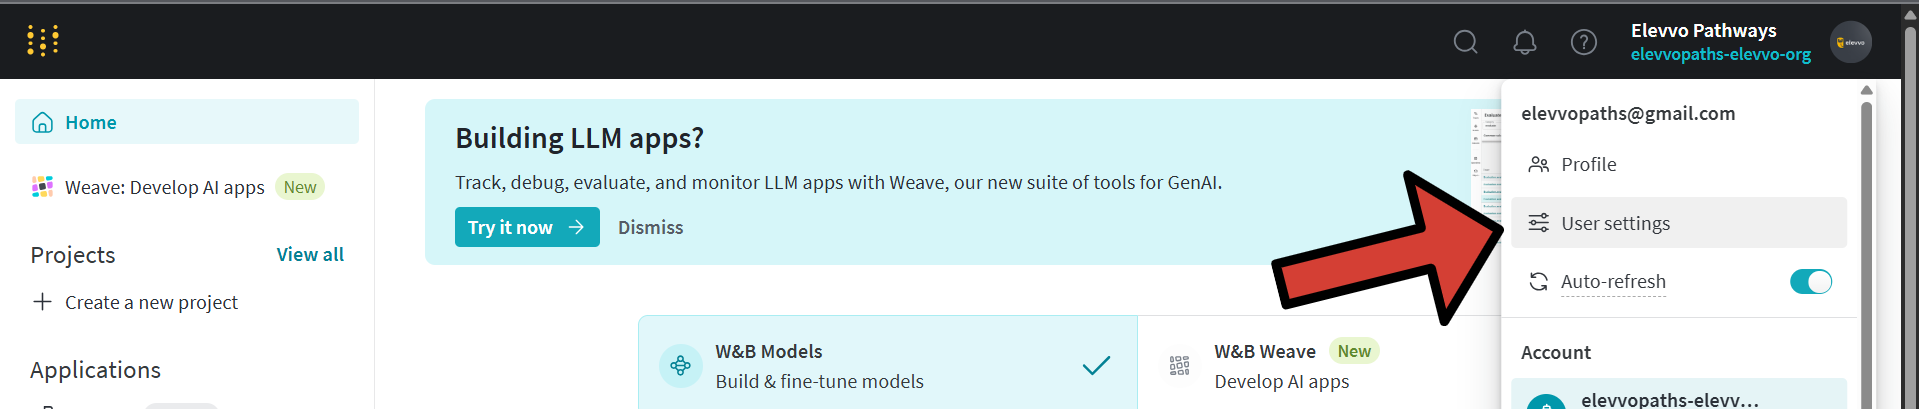

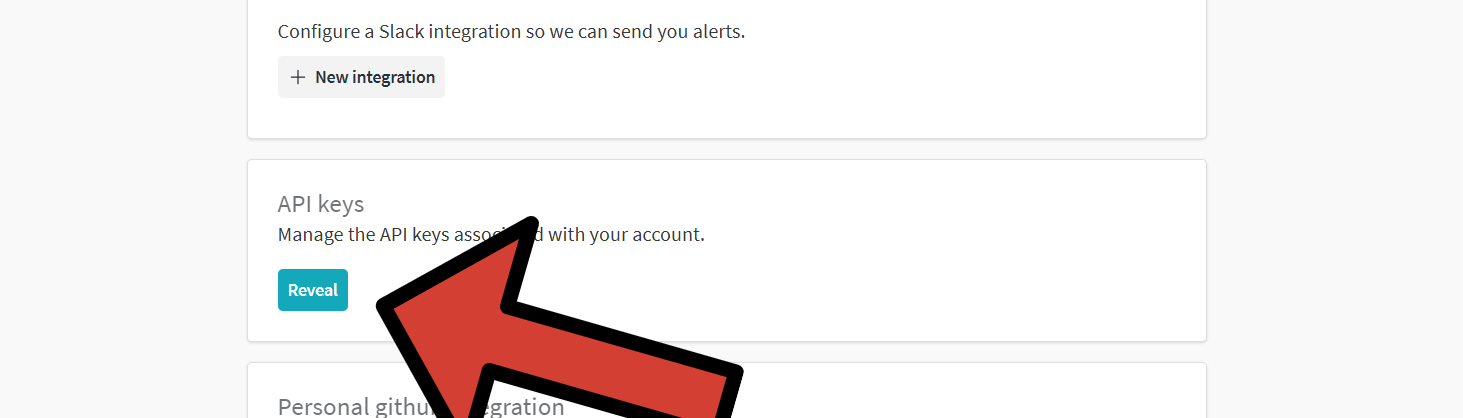

📌 next, we will set up and configure a Hugging Face Trainer to manage the training of the model

In [ ]:
# Define Trainer
args = TrainingArguments(
    output_dir="output",
    num_train_epochs=5,
    per_device_train_batch_size=1

)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

📌 the output of the next cell is:

  `Step:` Represents the number of batches of training data that have been processed by the model during training. In simpler terms, it's like a counter that increments every time the model sees a batch of data.

`Training Loss:` A measure of how well the model is currently predicting on the training data. A lower loss value generally indicates that the model is performing better and learning from the data. It is calculated after each step.

In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: labdelrahmanradwanl (labdelrahmanradwanl-msa-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,0.208500
1000,0.254200
1500,0.208500
2000,0.073000
2500,0.110500
3000,0.071600
3500,0.121300
4000,0.144600
4500,0.144800
5000,0.138600


TrainOutput(global_step=22285, training_loss=0.09572418367806533, metrics={'train_runtime': 3534.8272, 'train_samples_per_second': 6.304, 'train_steps_per_second': 6.304, 'total_flos': 2725578728027400.0, 'train_loss': 0.09572418367806533, 'epoch': 5.0})

In [ ]:
trainer.evaluate()

<class 'transformers.trainer_utils.EvalPrediction'>


{'eval_loss': 0.11894442141056061,
 'eval_accuracy': 0.9847533632286996,
 'eval_precision': 0.94,
 'eval_recall': 0.9463087248322147,
 'eval_f1': 0.9431438127090301,
 'eval_runtime': 16.2107,
 'eval_samples_per_second': 68.782,
 'eval_steps_per_second': 8.636,
 'epoch': 5.0}

📌 we can see that accuracy achieved on evaluation set is : 0.9847533632286996,


# Testing our fine-tuned model

📌 next, we will evaluate the classification model's performance on the validation data.

- The cell main function is to test the model's prediction ability on unseen data.
- It records the model's confidence for each prediction.
- This helps assess how well the model is performing.

- `tokenizer:` Prepares text for model.  
- `return_tensors:` PyTorch tensors
- `model(**inputs):` Runs the model, gets raw output.
- `softmax:` Converts output to probabilities.
- `cpu().detach().numpy():` Converts prediction to usable format.

📌 the output of this cell will be:

- `1. SequenceClassifierOutput:` This is the raw output from the model for each validation sample. It includes *'logits'* *(scores for each class)* and other information like hidden states or attentions.

- `tensor(...):` These lines show the predicted probabilities for each class after applying the softmax function to the logits. Notice they sum to 1, representing probabilities.

  📌 **For example, tensor([[9.9997e-01, 3.0854e-05]], device='cuda:0', grad_fn=<SoftmaxBackward0>)** indicates a very high probability (0.99997) for the first class and a very low one (0.000030854) for the second class for that particular sample.

In [ ]:
classoutput_list = []

for i in range(0, len(X_val)):
    text = X_val[i]
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors='pt').to('cuda')
    outputs = model(**inputs)
    print(outputs)
    predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
    print(predictions)
    predictions = predictions.cpu().detach().numpy()
    predictions

    classoutput_list.append(predictions.max())

SequenceClassifierOutput(loss=None, logits=tensor([[ 5.0961, -5.2893]], device='cuda:0', grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)
tensor([[9.9997e-01, 3.0878e-05]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
SequenceClassifierOutput(loss=None, logits=tensor([[ 5.0963, -5.2893]], device='cuda:0', grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)
tensor([[9.9997e-01, 3.0872e-05]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
SequenceClassifierOutput(loss=None, logits=tensor([[-2.5914,  4.2428]], device='cuda:0', grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)
tensor([[0.0011, 0.9989]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
SequenceClassifierOutput(loss=None, logits=tensor([[ 5.0951, -5.2885]], device='cuda:0', grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)
tensor([[9.9997e-01, 3.0936e-05]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
SequenceClassifierOutput(loss=None, logits=tensor([[ 5.0947, -5.2881]], devi

In [ ]:
print(predictions)

[[9.9996912e-01 3.0843057e-05]]


📌 remember that class 0 = not spam

1 = spam

In [ ]:
if predictions[0][0] > predictions[0][1]:
    print("It belongs to class:" , str(0))
else:
    print("It belongs to class:" , str(1))

It belongs to class: 0


In [ ]:
model_save_path = 'fine_tuned_model.pt'
torch.save(model.state_dict(), model_save_path)

In [ ]:
y_pred = [np.argmax(pred) for pred in classoutput_list]
accuracy = accuracy_score(y_val, y_pred) # Calculate accuracy score
accuracy

0.8663677130044843

📌 accuracy achieved here based only on validation data, not evaluation set used in evaluate() function : 'eval_accuracy': 0.9847533632286996,

📌 that's why it have different value
